In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore, f_oneway
import warnings
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import TargetEncoder, OneHotEncoder
from sklearn.impute import KNNImputer
from scipy.stats import chi2_contingency

warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [3]:
df_raw = pd.read_csv('../data/income_data.csv')

In [4]:
df_raw.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [8]:
df_raw.shape

(48842, 15)

In [6]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [7]:
numeric_cols = [col for col in df_raw.columns if df_raw[col].dtype in ['int64', 'float64']]
str_cols = [col for col in df_raw.columns if df_raw[col].dtype == 'object']

print(f'variables numericas {numeric_cols}')
print(f'-----------------------------------------------')
print(f'variables categoricas {str_cols}')

variables numericas ['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
-----------------------------------------------
variables categoricas ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country', 'income']


Vemos como se distribuye la variable objetivo

In [9]:
df_raw['income'].value_counts()

income
<=50K    37155
>50K     11687
Name: count, dtype: int64

## Análisis Univariado

###  Columnas numéricas

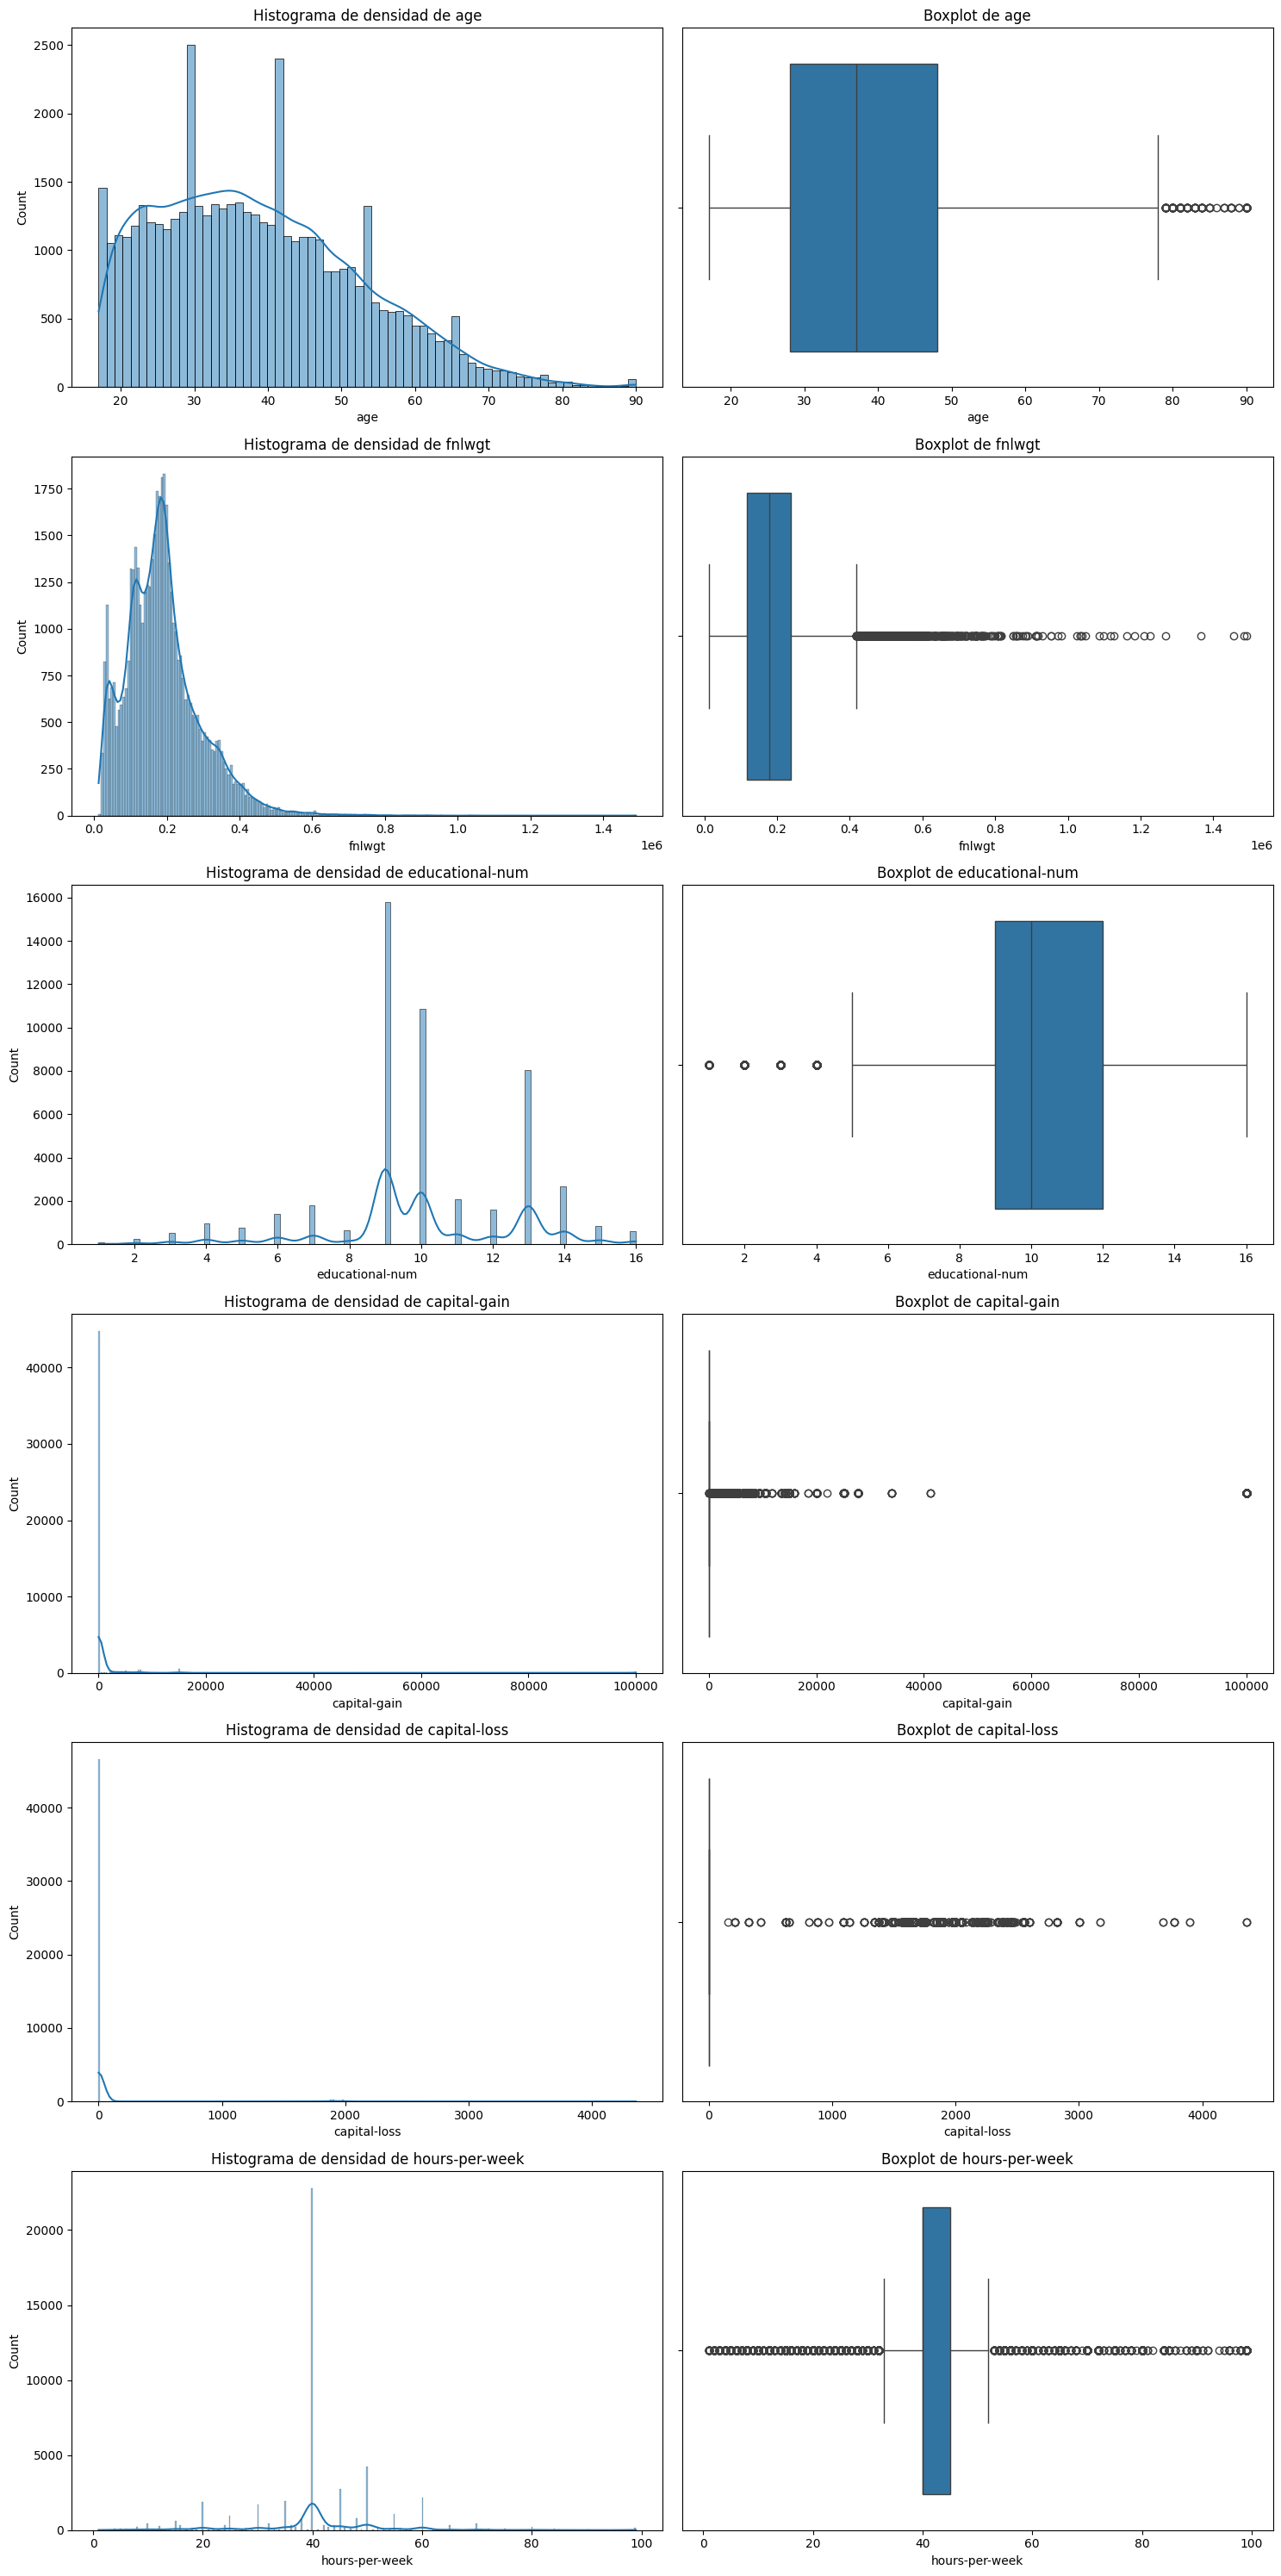

In [10]:
fig, axes = plt.subplots(nrows=len(df_raw.select_dtypes(include=[np.number]).columns), ncols=2, figsize=(15, 5 * len(df_raw.select_dtypes(include=[np.number]).columns)))

for i, column in enumerate(df_raw[numeric_cols]):
    # Histograma de densidad
    sns.histplot(df_raw[column], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'Histograma de densidad de {column}')
    
    # Boxplot
    sns.boxplot(x=df_raw[column], ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot de {column}')

plt.tight_layout()
plt.show()

In [15]:
# Describe básico de las columnas numéricas
df_raw[numeric_cols].describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


Podemos ver que la variable 'capital_loss' tiene muchos valores = 0, vamos a ver su distribución filtrando los 0

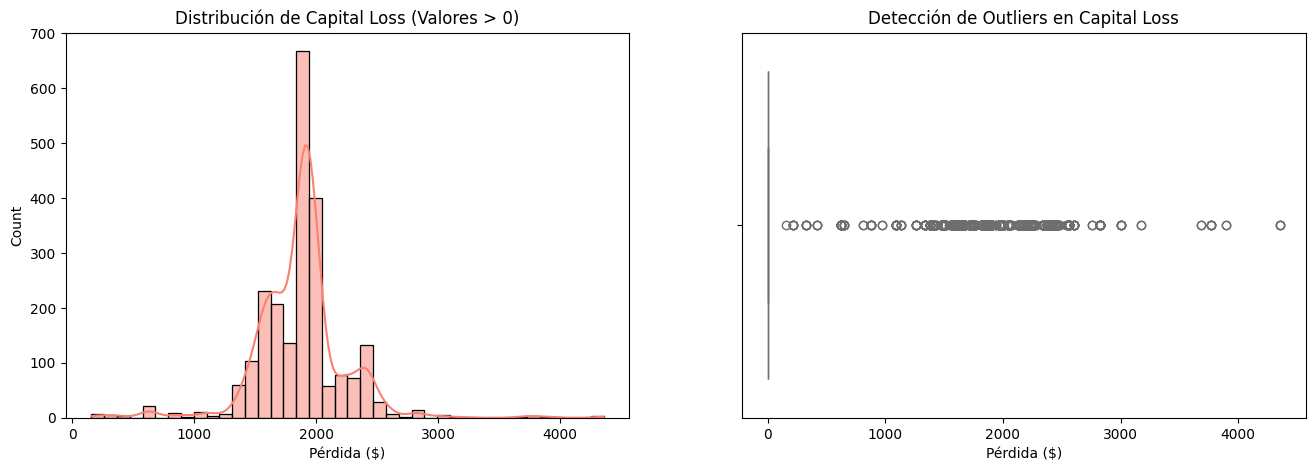

Registros con pérdida = 0: 46560 (95.33%)
Valor máximo de pérdida: 4356


In [11]:
# 1. Filtramos los valores mayores a 0 para el análisis de distribución
loss_nonzero = df_raw[df_raw['capital-loss'] > 0]['capital-loss']

# 2. Creamos las visualizaciones
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Histograma de pérdidas (solo valores > 0)
sns.histplot(loss_nonzero, bins=40, kde=True, ax=ax1, color='salmon')
ax1.set_title('Distribución de Capital Loss (Valores > 0)')
ax1.set_xlabel('Pérdida ($)')

# Boxplot para detectar valores extremos
sns.boxplot(x=df_raw['capital-loss'], ax=ax2, color='lightcoral')
ax2.set_title('Detección de Outliers en Capital Loss')
ax2.set_xlabel('Pérdida ($)')

plt.show()

# 3. Estadísticas de interés
total_records = len(df_raw)
zeros_count = len(df_raw[df_raw['capital-loss'] == 0])
print(f"Registros con pérdida = 0: {zeros_count} ({zeros_count/total_records*100:.2f}%)")
print(f"Valor máximo de pérdida: {df_raw['capital-loss'].max()}")

Podemos ver que la distribución se ve mucho mas clara, pero los registros = 0 representan un 95.33% de todos los valores de la variable, por lo cual eliminarlos posiblemente distorsione la variable. Tenemos prácticamente el mismo caso con la variable 'Capital_gain'

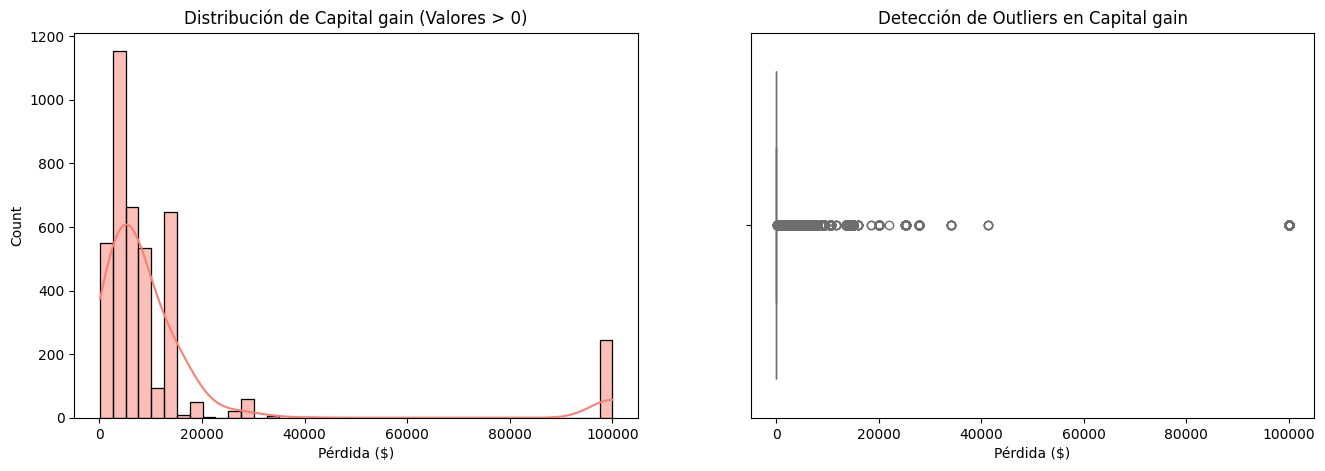

Registros con pérdida = 0: 44807 (91.74%)
Valor máximo de pérdida: 99999


In [12]:
# 1. Filtramos los valores mayores a 0 para el análisis de distribución
loss_nonzero = df_raw[df_raw['capital-gain'] > 0]['capital-gain']

# 2. Creamos las visualizaciones
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Histograma de pérdidas (solo valores > 0)
sns.histplot(loss_nonzero, bins=40, kde=True, ax=ax1, color='salmon')
ax1.set_title('Distribución de Capital gain (Valores > 0)')
ax1.set_xlabel('Pérdida ($)')

# Boxplot para detectar valores extremos
sns.boxplot(x=df_raw['capital-gain'], ax=ax2, color='lightcoral')
ax2.set_title('Detección de Outliers en Capital gain')
ax2.set_xlabel('Pérdida ($)')

plt.show()

# 3. Estadísticas de interés
total_records = len(df_raw)
zeros_count = len(df_raw[df_raw['capital-gain'] == 0])
print(f"Registros con pérdida = 0: {zeros_count} ({zeros_count/total_records*100:.2f}%)")
print(f"Valor máximo de pérdida: {df_raw['capital-gain'].max()}")

Vamos a aplicar un Logaritmo a las variables 'Capital-gain' y 'Capital-loss' para ver como cambia su distribución 

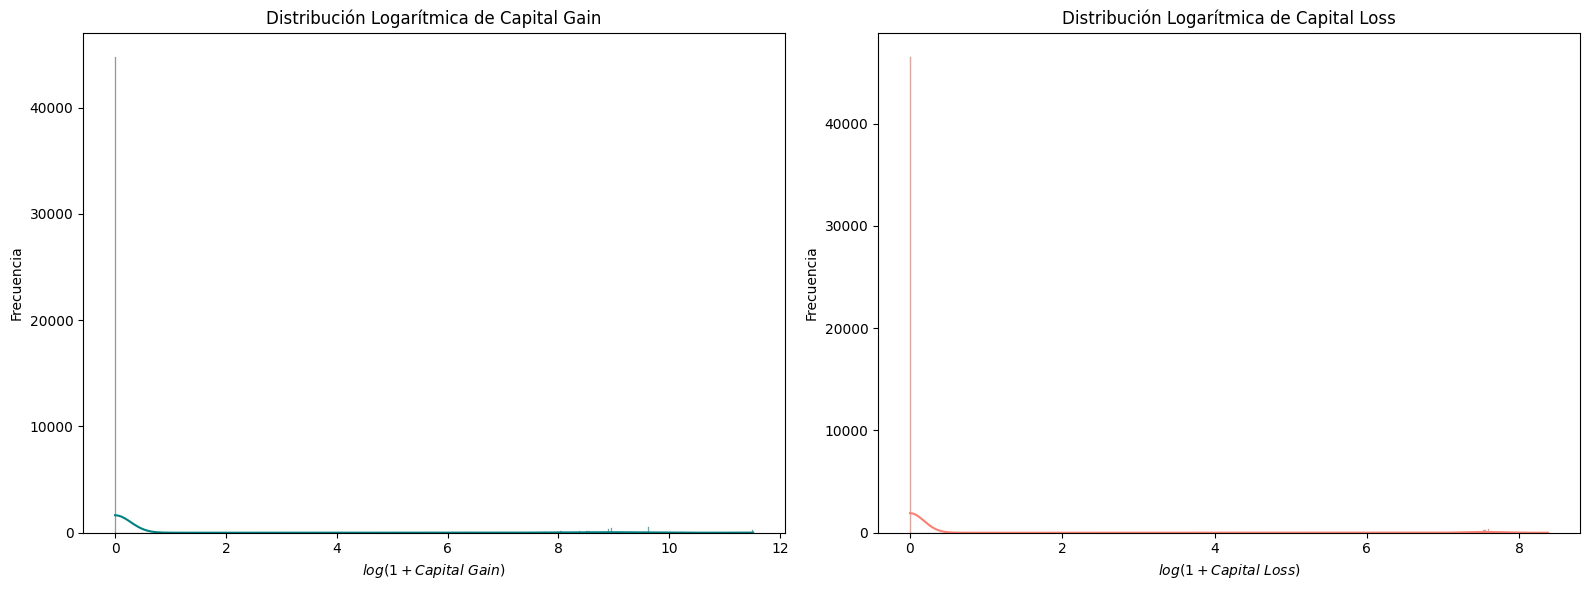

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Gráfico para Capital Gain usando log(1+x)
sns.histplot(np.log1p(df_raw['capital-gain']), kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribución Logarítmica de Capital Gain')
axes[0].set_xlabel('$log(1 + Capital\ Gain)$')
axes[0].set_ylabel('Frecuencia')

# 2. Gráfico para Capital Loss usando log(1+x)
sns.histplot(np.log1p(df_raw['capital-loss']), kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribución Logarítmica de Capital Loss')
axes[1].set_xlabel('$log(1 + Capital\ Loss)$')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

El cambio no es tan siquiera perceptible, más adelante tendremos que pensar como trataremos estas variables.

#### Hours-per-week